In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import glob
import json     

In [10]:
import pandas as pd, glob

for file in glob.glob('*.json'):
    df = pd.read_json(file, lines=True)
df = df.sort_values(by='timestamp', ascending=True)
df.head()

,id,device_id,device_name,timestamp,measurement_time_utc,date,data,processed_timestamp,annotations
0,1299333926,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:01:59+00:00,2001-01-01T00:01:59.000Z,2001-01-01,"[{'data': {'env': [22.42], 'leaf': [140, 343, ...",2026-06-09T12:45:56.756Z,[]
1,1344848666,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [22.08], 'leaf': [144, 342, ...",2026-06-09T12:45:56.756Z,[]
2,1599866163,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [21.99], 'leaf': [878, 656, ...",2026-06-09T12:45:56.756Z,[]
3,186516016,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [21.87], 'leaf': [41, 287, 2...",2026-06-09T12:45:56.756Z,[]
4,1459088716,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:02:00+00:00,2001-01-01T00:02:00.000Z,2001-01-01,"[{'data': {'env': [22.35], 'leaf': [357, 361, ...",2026-06-09T12:45:56.756Z,[]


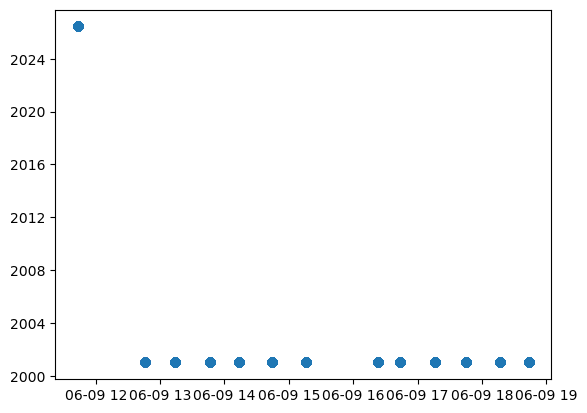

In [22]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df["processed_timestamp"] = pd.to_datetime(df["processed_timestamp"])

tdf = df[df["processed_timestamp"] > "2026-06-09 11:00:00"]
plt.scatter(tdf["processed_timestamp"], tdf["timestamp"])

In [25]:
df.iloc[0]["data"]

[{'data': {'env': [22.42],
   'leaf': [140, 343, 357, 359],
   'r_fluo': [8016, 8957, 9406, 9040],
   's_fluo': [1455, 1494, 1505, 1509],
   'sun': [743, 590, 568, 564],
   'timing': [20636141, 21341266]},
  'device': 'ambit',
  'endTicks': 978307300701,
  'measure_id': 65,
  'metadata': {'segments': [{'actinic': 0, 'freq': 4, 'pulses': 4}]},
  'sensor': 'AMBIT_1',
  'startTicks': 978307299925}]

In [ ]:
results = []
for row in df.itertuples():
    data = row.data
    try:
        data[0]["metadata"]["segments"]
    except Exception as e:
        info = data[0]["data"]
        # print(info)
        if "battery_v" in info.keys():
            results.append(row)


In [65]:
df_bat= pd.DataFrame(results)
inner = pd.json_normalize(df_bat['data'].str[0])   # -> data.battery_v, sensor, measure_id, ...
inner.index = df_bat.index
df_bat = pd.concat([df_bat.drop(columns='data'), inner], axis=1)
df_bat.head()

,Index,id,device_id,device_name,timestamp,measurement_time_utc,date,processed_timestamp,annotations,device,...,data.charge_ma,data.charge_status,data.db_online,data.input_ma,data.input_present,data.input_v,data.provisioned,data.publish_gate,data.system_v,data.wifi
0,182,441751963,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:05:02+00:00,2001-01-01 00:05:02+00:00,2001-01-01,2026-06-09 12:45:56.756000+00:00,[],None,...,0,0,True,239,True,5.04,True,True,4.04,True
1,183,99762516,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:05:03+00:00,2001-01-01 00:05:03+00:00,2001-01-01,2026-06-09 13:14:14.576000+00:00,[],None,...,490,2,True,532,True,6.84,True,True,3.98,True
2,312,1391434272,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:10:03+00:00,2001-01-01 00:10:03+00:00,2001-01-01,2026-06-09 13:14:14.576000+00:00,[],None,...,542,2,True,518,True,7.02,True,True,3.98,True
3,421,802135888,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:15:03+00:00,2001-01-01 00:15:03+00:00,2001-01-01,2026-06-09 13:46:50.166000+00:00,[],None,...,0,2,True,292,True,4.26,True,True,3.94,True
4,534,1727143778,28:37:2F:FF:E7:68,AmbyteOnAir,2001-01-01 00:20:03+00:00,2001-01-01 00:20:03+00:00,2001-01-01,2026-06-09 13:46:50.166000+00:00,[],None,...,0,2,True,279,True,4.20,True,True,3.94,True


<Axes: xlabel='Index'>

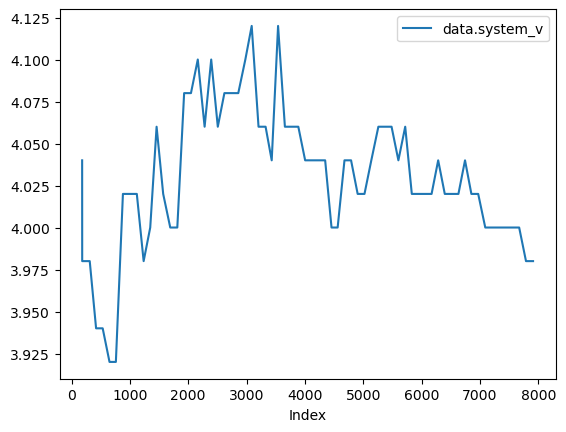

In [73]:
df_bat.plot(x="Index", y="data.system_v")

<Axes: xlabel='Index'>

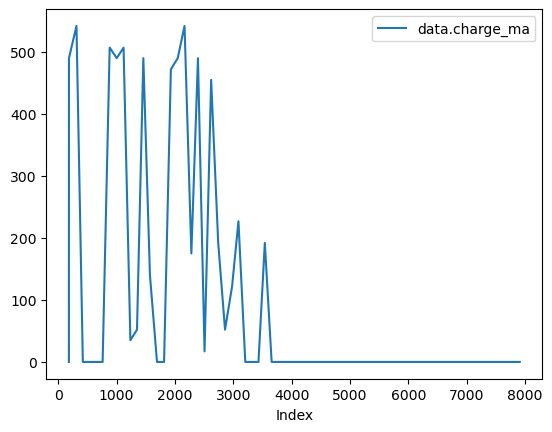

In [71]:
df_bat.plot(x="Index", y="data.charge_ma")

<Axes: xlabel='Index'>

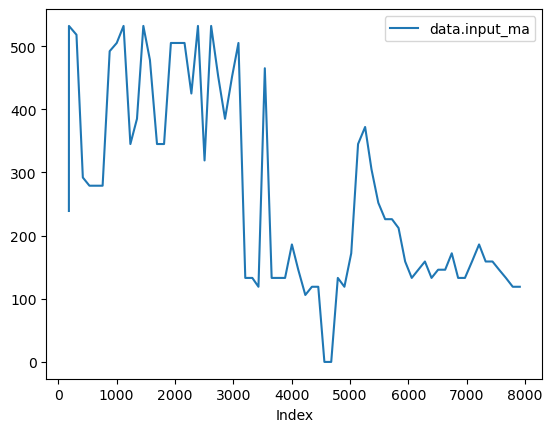

In [72]:
df_bat.plot(x="Index", y="data.input_ma")